In [ ]:
import prism
from pathlib import Path
from imagematerials.factory import ModelFactory, Sector
from imagematerials.maintenance import Maintenance, MaintenanceLinear

from imagematerials.model import (
    GenericMaterials,
    GenericStocks
)
import warnings
from imagematerials.preprocessing import get_preprocessing_data

: 

In [ ]:
base_dir = Path("..", "..", "image-materials", "data", "raw")
vhc_sector = get_preprocessing_data("vehicles", base_dir, cache = "vhc_sector2.nc")

circular_economy_scenario_dirs = {
        "slow": base_dir / 'circular_economy_scenarios' / 'slow'
    }
climate_policy_scenario_dir = base_dir / 'SSP2'

vhc_sector_slow = get_preprocessing_data("vehicles", base_dir, climate_policy_scenario_dir, circular_economy_scenario_dirs, cache = "vhc_sector_slow2.nc")


In [ ]:
# Define simulation parameters
time_start = 1970
complete_timeline = prism.Timeline(time_start, 2100, 1)
simulation_timeline = prism.Timeline(1970, 2100, 1)

scenario_list = {
    'standard_constant': {
        'label': 'Standard Lifetimes & Regular Maintenance',
        'circular_scen': 'standard',
        'maintenance_scen': 'constant'
    },
    'standard_linear': {
        'label': 'Standard Lifetimes & Linear Maintenance',
        'circular_scen': 'standard',
        'maintenance_scen': 'linear'
    },
    'slow_constant': {
        'label': 'Slow Lifetimes & Regular Maintenance',
        'circular_scen': 'slow',
        'maintenance_scen': 'constant'
    },
    'slow_linear': {
        'label': 'Slow Lifetimes & Linear Maintenance',
        'circular_scen': 'slow',
        'maintenance_scen': 'linear'
    }
}


In [ ]:
all_output = {}

for scen_id, scenario_config in scenario_list.items():   
    print(f"\n=== Running Scenario: {scen_id} ===")
    
    # Select the appropriate sector data based on circular economy scenario
    if scenario_config['circular_scen'] == 'standard':
        sector_data = vhc_sector
        print("Using standard sector data")
    elif scenario_config['circular_scen'] == 'slow':
        sector_data = vhc_sector_slow
        print("Using slow circular economy sector data")
    
    # Create factory with appropriate sector data
    factory = ModelFactory(
        sector_data, complete_timeline
    ).add(GenericStocks
    ).add(GenericMaterials)
    
    # Add the appropriate maintenance model based on maintenance scenario
    if scenario_config['maintenance_scen'] == 'constant':
        factory = factory.add(Maintenance)
        print("Using constant maintenance model")
    elif scenario_config['maintenance_scen'] == 'linear':
        # Pass vehicle_lifetimes as an explicit parameter to MaintenanceLinear
        factory = factory.add(MaintenanceLinear)
        print("Using linear maintenance model with explicit vehicle lifetimes")
    
    # Finish model creation
    model = factory.finish()
    
    # Run simulation
    
    with warnings.catch_warnings():
        warnings.filterwarnings("ignore")
        model.simulate(simulation_timeline)
    
    # Store results
    all_output[scen_id] = {
        'model': model,
        'inflow_maintenance': model.inflow_maintenance.to_array(),
        'circular_scenario': scenario_config['circular_scen'],
        'maintenance_scenario': scenario_config['maintenance_scen'],
        'label': scenario_config['label']
    }
    
    print(f"✓ Completed: {scen_id}")

print(f"\n=== All {len(all_output)} scenarios completed successfully ===")
print("Available scenarios:", list(all_output.keys()))



=== Running Scenario: standard_constant ===
Using standard sector data
Using constant maintenance model
✓ Completed: standard_constant

=== Running Scenario: standard_linear ===
Using standard sector data
Initialized MaintenanceLinear with 47 maintenance types
Using linear maintenance model with explicit vehicle lifetimes
✓ Completed: standard_linear

=== All 2 scenarios completed successfully ===
Available scenarios: ['standard_constant', 'standard_linear']


In [ ]:
all_output['standard_linear']['inflow_maintenance']

<xarray.DataArray (time: 131, Region: 26, Type: 47, material: 14)> Size: 18MB
<Quantity([[[[0.00000000e+00 0.00000000e+00 0.00000000e+00 ... 0.00000000e+00
    0.00000000e+00 0.00000000e+00]
   [0.00000000e+00 0.00000000e+00 0.00000000e+00 ... 0.00000000e+00
    0.00000000e+00 0.00000000e+00]
   [0.00000000e+00 0.00000000e+00 0.00000000e+00 ... 0.00000000e+00
    0.00000000e+00 0.00000000e+00]
   ...
   [7.60534923e+03 2.05354883e+04 3.03896775e+03 ... 9.00202189e+04
    0.00000000e+00 0.00000000e+00]
   [0.00000000e+00 0.00000000e+00 0.00000000e+00 ... 0.00000000e+00
    0.00000000e+00 0.00000000e+00]
   [1.32834114e+00 3.58670366e+00 5.30782446e-01 ... 1.57228230e+01
    0.00000000e+00 0.00000000e+00]]

  [[0.00000000e+00 0.00000000e+00 0.00000000e+00 ... 0.00000000e+00
    0.00000000e+00 0.00000000e+00]
   [0.00000000e+00 0.00000000e+00 0.00000000e+00 ... 0.00000000e+00
    0.00000000e+00 0.00000000e+00]
   [0.00000000e+00 0.00000000e+00 0.00000000e+00 ... 0.00000000e+00
    0.00000000e+00 0.00000000e+00]
...
   [2.34235373e+06 6.32467704e+06 9.35964571e+05 ... 2.77251167e+07
    0.00000000e+00 0.00000000e+00]
   [0.00000000e+00 0.00000000e+00 0.00000000e+00 ... 0.00000000e+00
    0.00000000e+00 0.00000000e+00]
   [1.56174660e+01 4.21693049e+01 6.24047286e+00 ... 1.84855115e+02
    0.00000000e+00 0.00000000e+00]]

  [[0.00000000e+00 0.00000000e+00 0.00000000e+00 ... 0.00000000e+00
    0.00000000e+00 0.00000000e+00]
   [0.00000000e+00 0.00000000e+00 0.00000000e+00 ... 0.00000000e+00
    0.00000000e+00 0.00000000e+00]
   [0.00000000e+00 0.00000000e+00 0.00000000e+00 ... 0.00000000e+00
    0.00000000e+00 0.00000000e+00]
   ...
   [1.25895746e+06 3.39935821e+06 5.03057915e+05 ... 1.49015677e+07
    0.00000000e+00 0.00000000e+00]
   [0.00000000e+00 0.00000000e+00 0.00000000e+00 ... 0.00000000e+00
    0.00000000e+00 0.00000000e+00]
   [1.71378782e+01 4.62746268e+01 6.84800361e+00 ... 2.02851374e+02
    0.00000000e+00 0.00000000e+00]]]], 'count')>
Coordinates:
  * time      (time) int32 524B 1970 1971 1972 1973 1974 ... 2097 2098 2099 2100
  * Region    (Region) <U2 208B '1' '2' '3' '4' '5' ... '22' '23' '24' '25' '26'
  * Type      (Type) <U35 7kB 'Bikes' ... 'Regular Buses - Trolley'
  * material  (material) <U9 504B 'Aluminium' 'Co' 'Cu' ... 'Steel' 'Ti' 'Wood'


Processing scenario: standard_constant
maintenance - Data shape: (131, 14)
maintenance - Data columns: ['Aluminium', 'Co', 'Cu', 'Glass', 'Li', 'Mn', 'Nd', 'Ni', 'Pb', 'Plastics', 'Rubber', 'Steel', 'Ti', 'Wood']
production - Data shape: (131, 14)
production - Data columns: ['Aluminium', 'Co', 'Cu', 'Glass', 'Li', 'Mn', 'Nd', 'Ni', 'Pb', 'Plastics', 'Rubber', 'Steel', 'Ti', 'Wood']

Processing scenario: standard_linear
maintenance - Data shape: (131, 14)
maintenance - Data columns: ['Aluminium', 'Co', 'Cu', 'Glass', 'Li', 'Mn', 'Nd', 'Ni', 'Pb', 'Plastics', 'Rubber', 'Steel', 'Ti', 'Wood']
production - Data shape: (131, 14)
production - Data columns: ['Aluminium', 'Co', 'Cu', 'Glass', 'Li', 'Mn', 'Nd', 'Ni', 'Pb', 'Plastics', 'Rubber', 'Steel', 'Ti', 'Wood']


c:\Users\5982758\AppData\Local\anaconda3\envs\materials\lib\site-packages\xarray\core\indexing.py:1522: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  array[key] = value
c:\Users\5982758\AppData\Local\anaconda3\envs\materials\lib\site-packages\xarray\core\indexing.py:1522: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  array[key] = value
c:\Users\5982758\AppData\Local\anaconda3\envs\materials\lib\site-packages\xarray\core\indexing.py:1522: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  array[key] = value
c:\Users\5982758\AppData\Local\anaconda3\envs\materials\lib\site-packages\xarray\core\indexing.py:1522: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  array[key] = value
c:\Users\5982758\AppData\Local\anaconda3\envs\materials\lib\site-packages\xarray\core\indexing.py:1522: UnitStrippedWarning: The unit of the quantity is

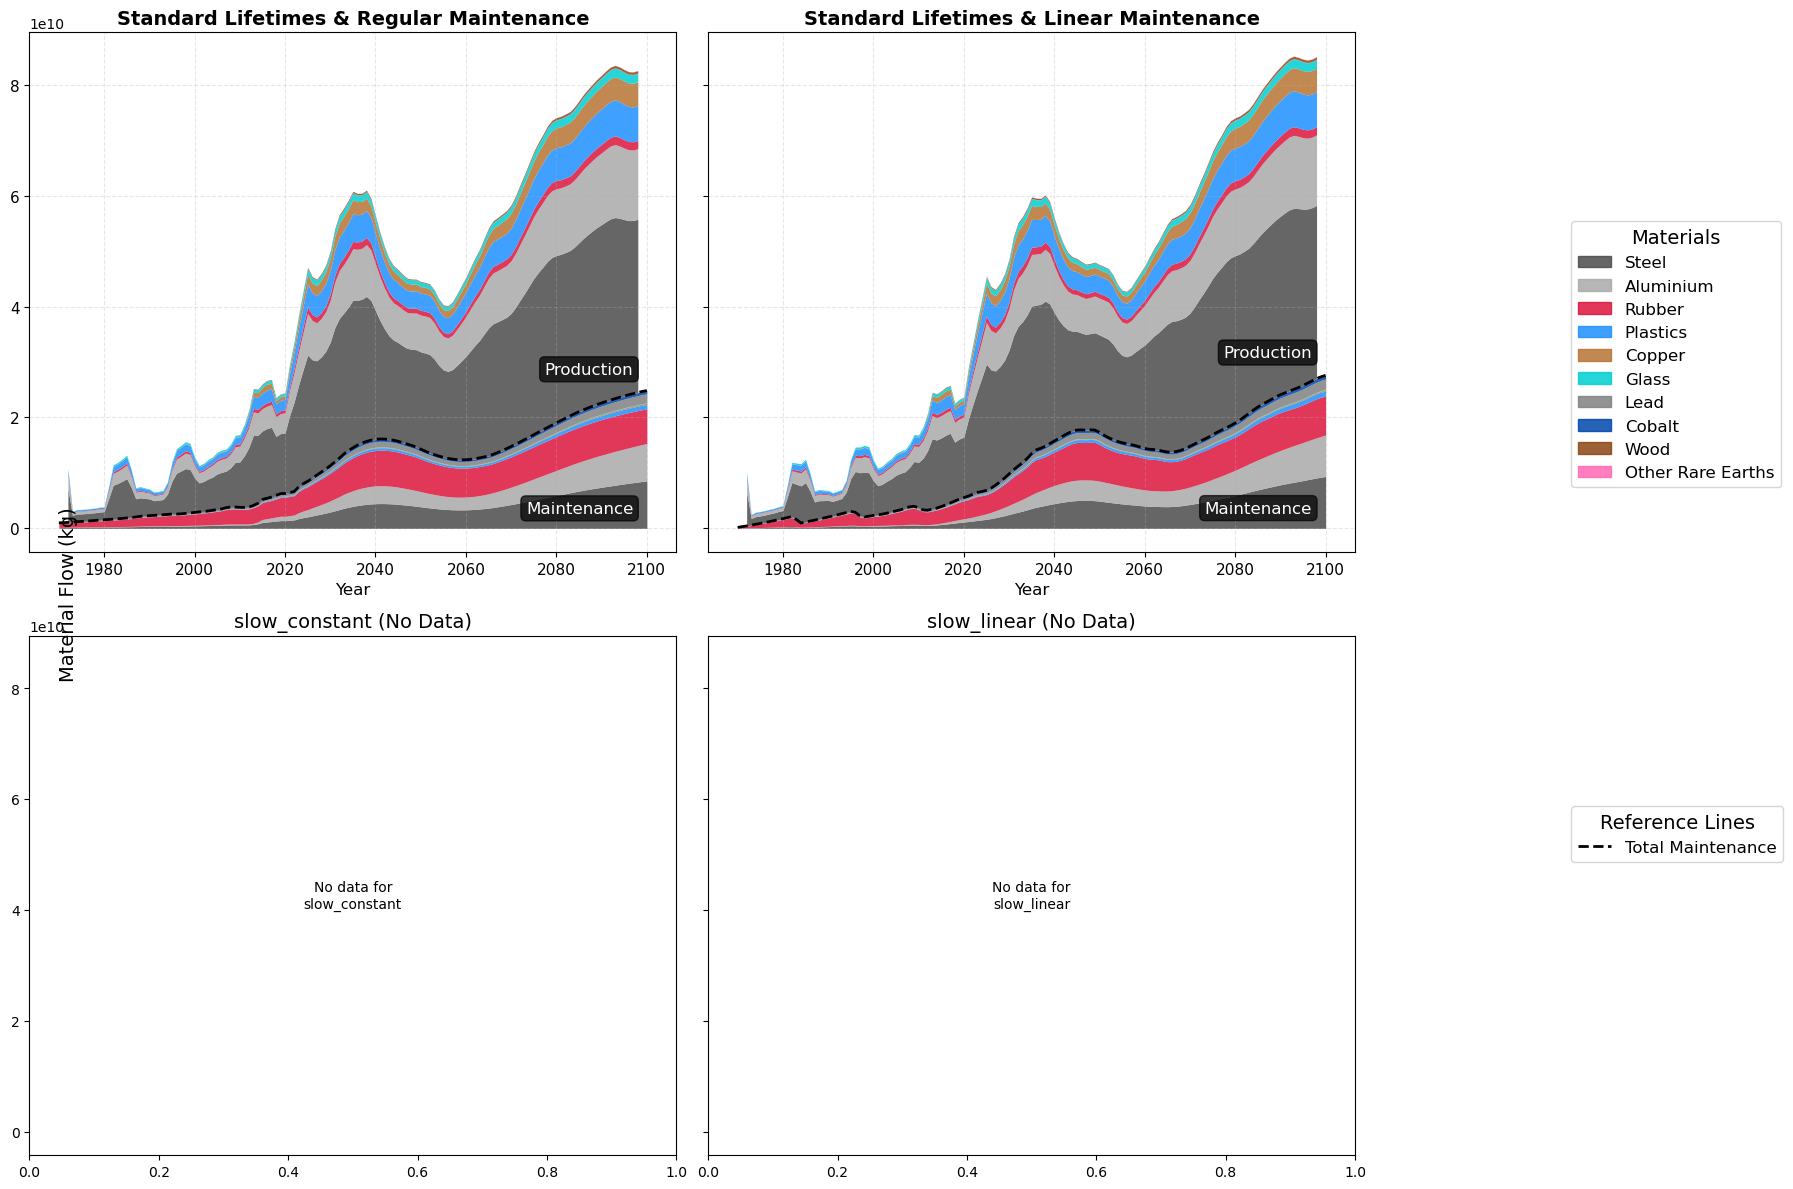

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from imagematerials.concepts import knowledge_graph


"""
Create 2x2 subplot showing maintenance + production for all four scenarios
with materials stacked and uniform coloring across plots.
"""

# Define material colors (customize as needed)
material_colors = {
    "Steel": "#4B4B4B",
    "Aluminium": "#A9A9A9",
    "Others": "#F0E68C",
    "Plastics": "#1E90FF",
    "Copper": "#B87333",
    "Rubber": "#DC143C",
    "Glass": "#00CED1",
    "Wood": "#8B4513",
    "Fluids": "#FF6347",
    "Lead": "#808080",
    "Neodymium": "#D2691E",  # will be removed after grouping
    "Cobalt": "#0047AB",  # cobalt blue
    "Other Rare Earths": "#FF69B4"  # pink
}

maintenance_types = [
    "Midi Buses",
    "Regular Buses", 
    "Trains",
    "High Speed Trains",
    "Light Commercial Vehicles",
    "Cars"
]



# Helper function to process data for each scenario
def process_scenario_data(scenario_data):
    # Get maintenance and production data, sum over Region and Type
    maint_data = scenario_data['inflow_maintenance']
    prod_data = scenario_data["model"].inflow_materials.to_array()

    maint_data = knowledge_graph.rebroadcast_xarray(maint_data, output_coords=maintenance_types, dim="Type").sum(dim=['Region', 'Type'])
    prod_data = knowledge_graph.rebroadcast_xarray(prod_data, output_coords=maintenance_types, dim="Type").sum(dim=['Region', 'Type'])

        
    # Convert to pandas DataFrames
    maint_df = maint_data.to_pandas()
    prod_df = prod_data.to_pandas() 
    prod_df = prod_df.rolling(window=5, center=True).mean()
    
    # Process both dataframes similarly
    for df, name in [(maint_df, 'maintenance'), (prod_df, 'production')]:
        if df is None:
            continue
            
        print(f"{name} - Data shape: {df.shape}")
        print(f"{name} - Data columns: {df.columns.tolist()}")
        
        # Group rare earth elements
        rare_earths = ["Nd", "Mn", "Ni", "Ti", "Li"]
        existing_rare_earths = [re for re in rare_earths if re in df.columns]
        if existing_rare_earths:
            df["Other Rare Earths"] = df[existing_rare_earths].sum(axis=1)
            df.drop(columns=existing_rare_earths, inplace=True, errors="ignore")
        
        # Rename materials for better display
        rename_map = {
            "Pb": "Lead",
            "Co": "Cobalt", 
            "Cu": "Copper",
            "Al": "Aluminum"
        }
        df.rename(columns=rename_map, inplace=True)
        
        # Filter from 2000 onwards
        df = df[df.index >= 2010]
        
        # Keep only non-zero materials
        valid_materials = (df != 0).any(axis=0)
        df = df.loc[:, valid_materials]
    
    # Update the original dataframes
    if prod_df is not None:
        # Ensure both have same columns for consistent plotting
        all_materials = set(maint_df.columns) | set(prod_df.columns)
        for mat in all_materials:
            if mat not in maint_df.columns:
                maint_df[mat] = 0
            if mat not in prod_df.columns:
                prod_df[mat] = 0
        
        # Sort columns by total sum (maintenance + production)
        total_materials = maint_df + prod_df
        sorted_cols = total_materials.sum(axis=0).sort_values(ascending=False).index
        maint_df = maint_df[sorted_cols]
        prod_df = prod_df[sorted_cols]
    else:
        # Sort maintenance only
        sorted_cols = maint_df.sum(axis=0).sort_values(ascending=False).index
        maint_df = maint_df[sorted_cols]
    
    return maint_df, prod_df

# Process all scenarios
processed_data = {}
for scen_id, scen_data in all_output.items():
    print(f"\nProcessing scenario: {scen_id}")
    maint_df, prod_df = process_scenario_data(scen_data)
    if not maint_df.empty:
        processed_data[scen_id] = {'maintenance': maint_df, 'production': prod_df}


# Get all unique materials across scenarios for consistent coloring
all_materials = set()
for scen_data in processed_data.values():
    all_materials.update(scen_data['maintenance'].columns)
    if scen_data['production'] is not None:
        all_materials.update(scen_data['production'].columns)

# Update material colors to include any missing materials
for material in all_materials:
    if material not in material_colors:
        material_colors[material] = '#999999'  # Default gray

# Create 2x2 subplot
fig, axes = plt.subplots(2, 2, figsize=(16, 12), sharey=True)
axes = axes.flatten()

# Plot each scenario
scenario_order = ['standard_constant', 'standard_linear', 'slow_constant', 'slow_linear']

for i, scen_id in enumerate(scenario_order):
    ax = axes[i]
    
    if scen_id not in processed_data:
        ax.text(0.5, 0.5, f"No data for\n{scen_id}", 
                ha='center', va='center', transform=ax.transAxes)
        ax.set_title(f"{scen_id} (No Data)", fontsize=14)
        continue
        
    maint_df = processed_data[scen_id]['maintenance']
    prod_df = processed_data[scen_id]['production']
    
    # Plot maintenance (bottom layer)
    colors_list = [material_colors.get(mat, '#999999') for mat in maint_df.columns]
    maint_df.plot.area(
        ax=ax, 
        stacked=True, 
        color=colors_list,
        alpha=0.85, 
        linewidth=0
    )
    ax.get_legend().remove()
    
    # Plot production stacked above maintenance
    if prod_df is not None:
        maintenance_total = maint_df.sum(axis=1)
        prod_bottom = maintenance_total.copy()
        
        for mat in prod_df.columns:
            if mat in prod_df.columns and not prod_df[mat].isna().all():
                top = prod_bottom + prod_df[mat]
                ax.fill_between(
                    prod_df.index,
                    prod_bottom,
                    top,
                    color=material_colors.get(mat, '#999999'),
                    alpha=0.85,
                    linewidth=0
                )
                prod_bottom = top
        
        # Plot total maintenance line
        ax.plot(
            maintenance_total.index, 
            maintenance_total, 
            color="black", 
            linewidth=2, 
            linestyle="--"
        )
    else:
        # Just maintenance
        maintenance_total = maint_df.sum(axis=1)
        ax.plot(
            maintenance_total.index, 
            maintenance_total, 
            color="black", 
            linewidth=2, 
            linestyle="--"
        )
    
    # Styling
    scenario_info = all_output[scen_id]
    title = scenario_info['label']
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.set_xlabel("Year", fontsize=12)
    ax.tick_params(labelsize=11)
    ax.grid(visible=True, linestyle="--", alpha=0.3)
    
    # Add labels
    if len(maintenance_total) > 0:
        # Maintenance label
        ax.text(
            maintenance_total.index[-1] - 3,
            ax.get_ylim()[0] + 0.07 * (ax.get_ylim()[1] - ax.get_ylim()[0]),
            "Maintenance",
            color="white", fontsize=12, ha="right", va="bottom",
            bbox=dict(boxstyle="round,pad=0.3", facecolor="black", alpha=0.7)
        )
        
        # Production label (if exists)
        if prod_df is not None:
            ax.text(
                maintenance_total.index[-1] - 3,
                maintenance_total.iloc[-1] * 1.1,
                "Production",
                color="white", fontsize=12, ha="right", va="bottom",
                bbox=dict(boxstyle="round,pad=0.3", facecolor="black", alpha=0.7)
            )

# Add shared Y label
fig.text(0.04, 0.5, 'Material Flow (kg)', va='center', rotation='vertical', fontsize=14)

# Create shared legend for materials
if processed_data:
    # Get materials from the first scenario for legend order
    first_scenario = list(processed_data.values())[0]
    legend_materials = first_scenario['maintenance'].columns.tolist()
    
    # Create legend handles
    legend_handles = [mpatches.Rectangle((0,0),1,1, color=material_colors[mat], alpha=0.85) 
                        for mat in legend_materials]
    
    # Add materials legend
    fig.legend(
        legend_handles, 
        legend_materials,
        title="Materials", 
        bbox_to_anchor=(0.98, 0.7), 
        loc="center left", 
        fontsize=12, 
        title_fontsize=14
    )
    
    # Add reference line legend
    ref_handles = [plt.Line2D([0], [0], color='black', linewidth=2, linestyle='--')]
    ref_labels = ["Total Maintenance"]
    
    fig.legend(
        ref_handles, 
        ref_labels,
        title="Reference Lines", 
        bbox_to_anchor=(0.98, 0.3), 
        loc="center left", 
        fontsize=12, 
        title_fontsize=14
    )

# Layout optimization
plt.tight_layout()
plt.subplots_adjust(right=0.85)  # Space for legends
plt.show()


c:\Users\5982758\AppData\Local\anaconda3\envs\materials\lib\site-packages\xarray\core\indexing.py:1522: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  array[key] = value
c:\Users\5982758\AppData\Local\anaconda3\envs\materials\lib\site-packages\xarray\core\indexing.py:1522: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  array[key] = value
c:\Users\5982758\AppData\Local\anaconda3\envs\materials\lib\site-packages\xarray\core\indexing.py:1522: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  array[key] = value
c:\Users\5982758\AppData\Local\anaconda3\envs\materials\lib\site-packages\xarray\core\indexing.py:1522: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  array[key] = value


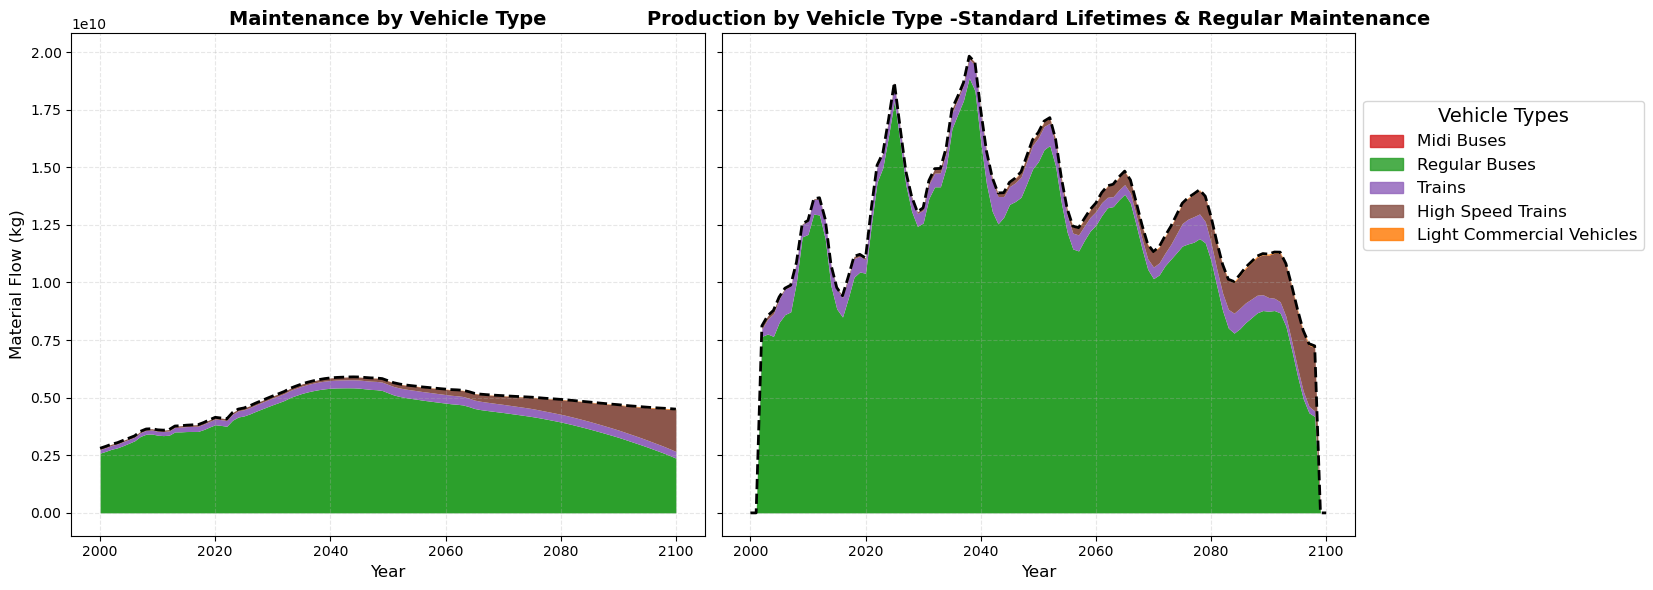

c:\Users\5982758\AppData\Local\anaconda3\envs\materials\lib\site-packages\xarray\core\indexing.py:1522: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  array[key] = value
c:\Users\5982758\AppData\Local\anaconda3\envs\materials\lib\site-packages\xarray\core\indexing.py:1522: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  array[key] = value
c:\Users\5982758\AppData\Local\anaconda3\envs\materials\lib\site-packages\xarray\core\indexing.py:1522: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  array[key] = value
c:\Users\5982758\AppData\Local\anaconda3\envs\materials\lib\site-packages\xarray\core\indexing.py:1522: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  array[key] = value


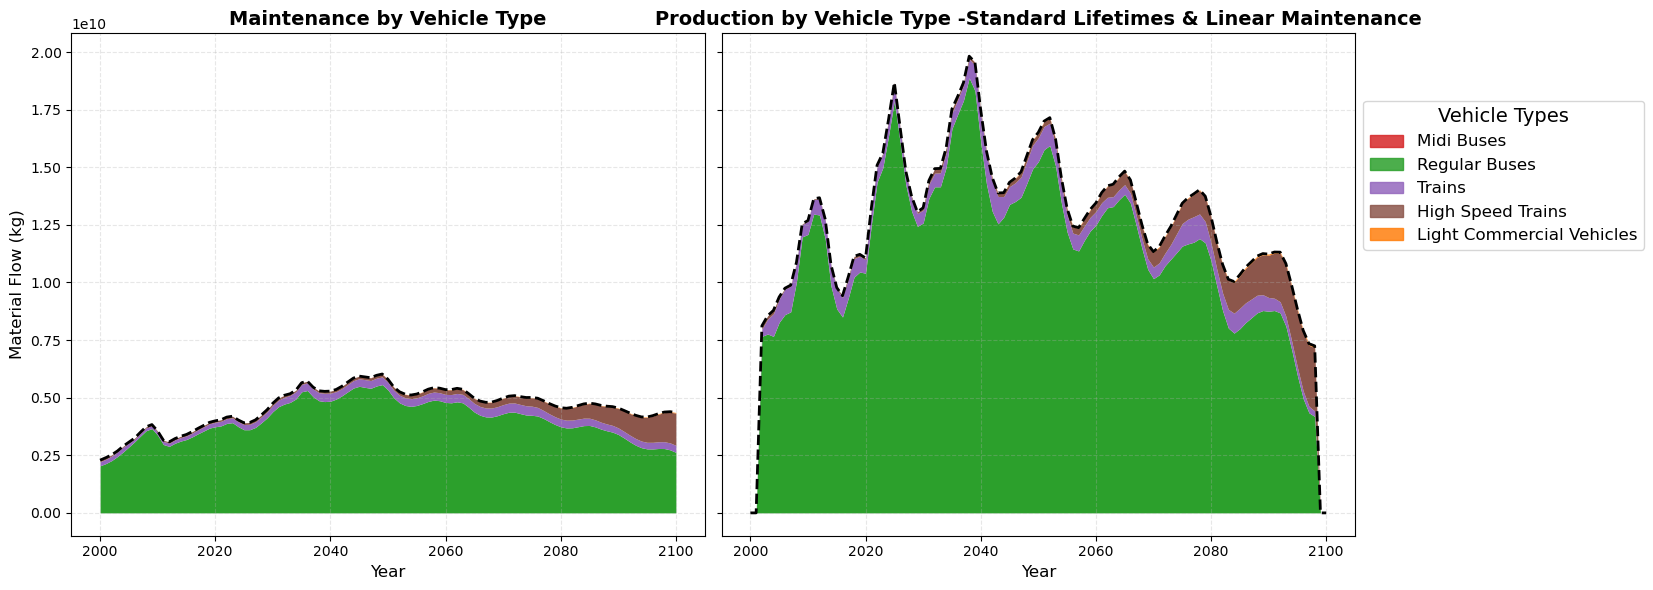

c:\Users\5982758\AppData\Local\anaconda3\envs\materials\lib\site-packages\xarray\core\indexing.py:1522: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  array[key] = value
c:\Users\5982758\AppData\Local\anaconda3\envs\materials\lib\site-packages\xarray\core\indexing.py:1522: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  array[key] = value
c:\Users\5982758\AppData\Local\anaconda3\envs\materials\lib\site-packages\xarray\core\indexing.py:1522: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  array[key] = value
c:\Users\5982758\AppData\Local\anaconda3\envs\materials\lib\site-packages\xarray\core\indexing.py:1522: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  array[key] = value


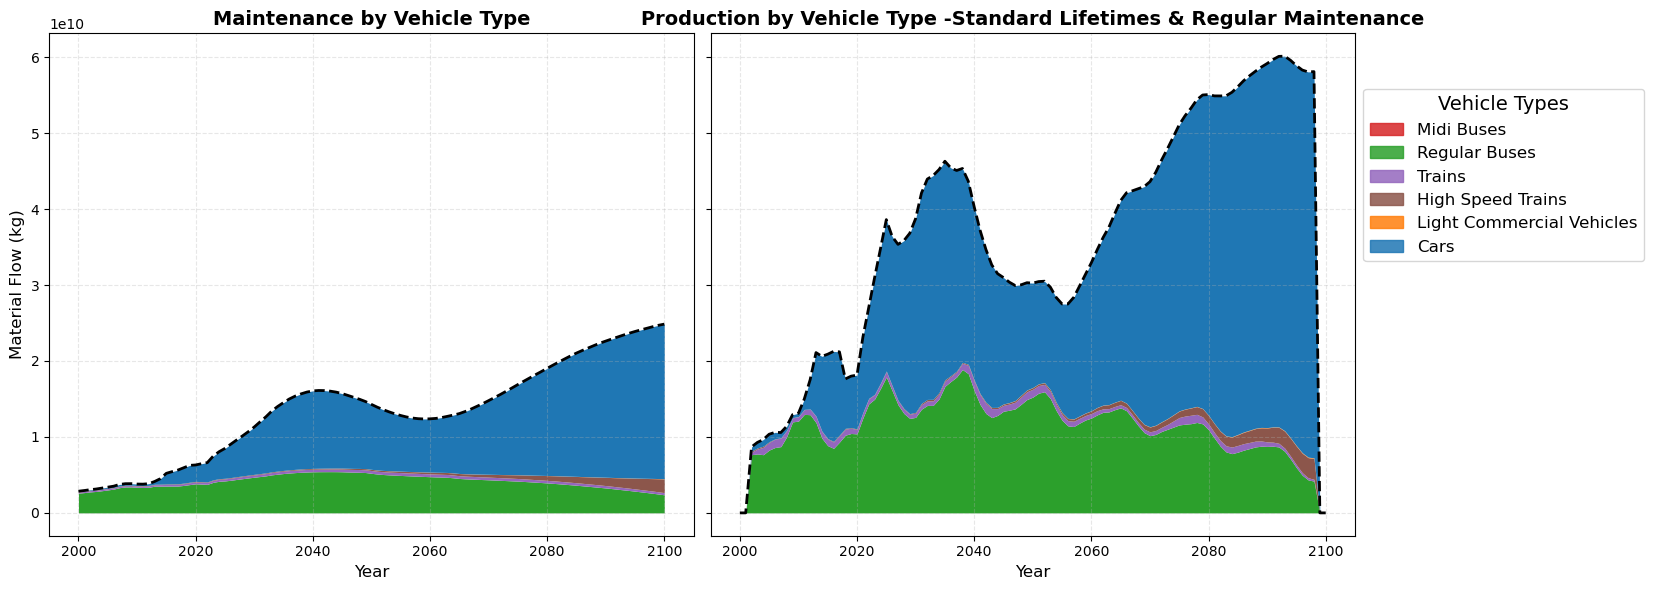

c:\Users\5982758\AppData\Local\anaconda3\envs\materials\lib\site-packages\xarray\core\indexing.py:1522: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  array[key] = value
c:\Users\5982758\AppData\Local\anaconda3\envs\materials\lib\site-packages\xarray\core\indexing.py:1522: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  array[key] = value
c:\Users\5982758\AppData\Local\anaconda3\envs\materials\lib\site-packages\xarray\core\indexing.py:1522: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  array[key] = value
c:\Users\5982758\AppData\Local\anaconda3\envs\materials\lib\site-packages\xarray\core\indexing.py:1522: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  array[key] = value


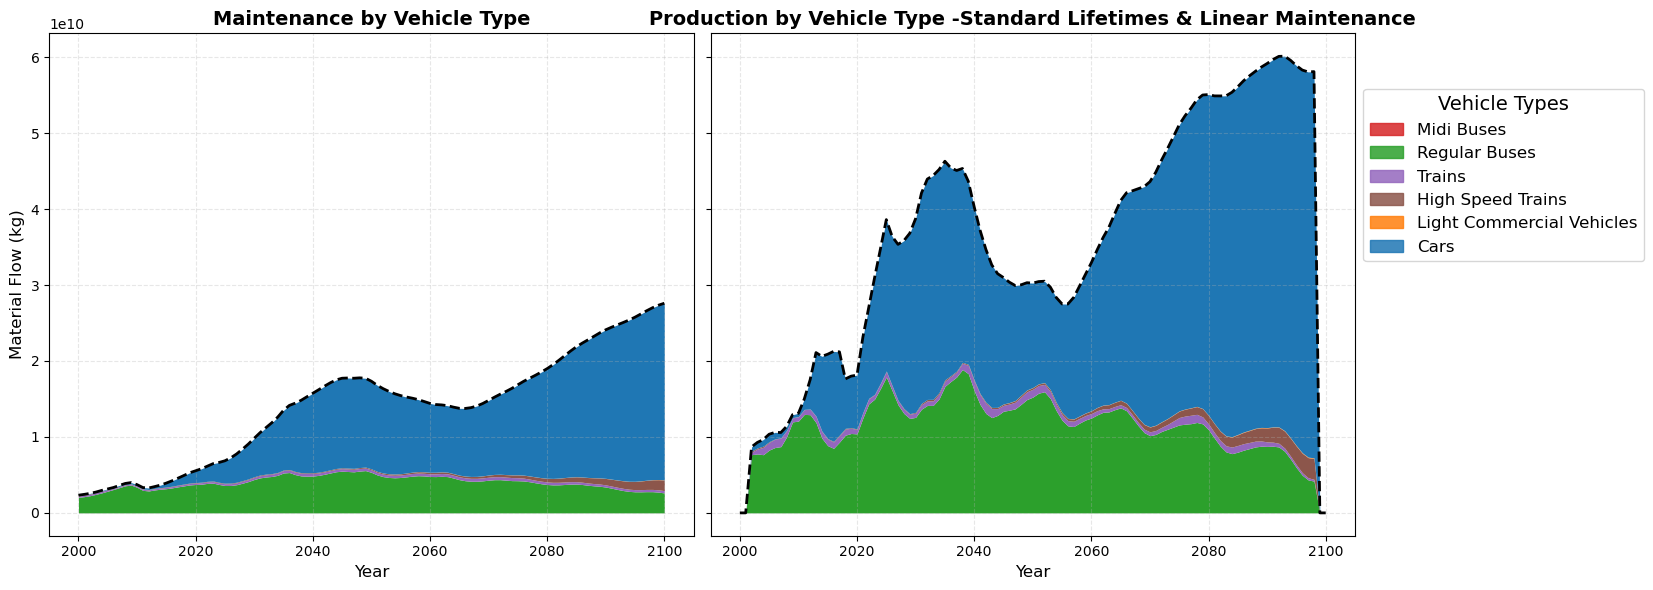

In [ ]:
# Import knowledge graph (assuming it's available)
from imagematerials.concepts import knowledge_graph
# Define colors for vehicle types
type_colors = {
    "Cars": "#1f77b4",
    "Light Commercial Vehicles": "#ff7f0e",
    "Regular Buses": "#2ca02c",
    "Midi Buses": "#d62728",
    "Trains": "#9467bd",
    "High Speed Trains": "#8c564b",
    "Freight Trains": "#e377c2",
    "Bikes": "#7f7f7f",
    "Inland Ships": "#bcbd22"
}

def plot_production_vs_maintenance_by_type(all_output, target_types, scenario):
    """
    Create production vs maintenance plot for standard_constant scenario
    aggregated by target vehicle types using knowledge graph.
    """
    
    # Get maintenance and production data (keep Type dimension)
    maint_data = all_output[scenario]['inflow_maintenance'].sum(dim=['Region','material'])  # Sum only Region
    prod_data = all_output[scenario]['model'].inflow_materials.to_array().sum(dim=['Region','material'])     # Sum only Region

    # Aggregate to target types using knowledge graph
    maint_df = knowledge_graph.rebroadcast_xarray(maint_data, output_coords=target_types, dim="Type").to_pandas()
    prod_df = knowledge_graph.rebroadcast_xarray(prod_data, output_coords=target_types, dim="Type").to_pandas()
    
    # Apply rolling average to production for smoothing
    #prod_df = prod_df.rolling(window=5, center=True).mean()
    
    # Filter from 2000 onwards
    maint_df = maint_df[maint_df.index >= 2000]
    prod_df = prod_df[prod_df.index >= 2000]
    prod_df = prod_df.rolling(window=5, center=True).mean()
    

    # Create 1x2 subplot (maintenance vs production)
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6), sharey=True)
    
    # Plot maintenance by vehicle type
    colors_list = [type_colors.get(vtype, '#999999') for vtype in maint_df.columns]
    maint_df.plot.area(
        ax=ax1,
        stacked=True,
        color=colors_list,
        linewidth=0
    )
    ax1.set_title("Maintenance by Vehicle Type", fontsize=14, fontweight='bold')
    ax1.set_xlabel("Year", fontsize=12)
    ax1.set_ylabel("Material Flow (kg)", fontsize=12)
    ax1.grid(visible=True, linestyle="--", alpha=0.3)
    ax1.get_legend().remove()
    
    # Plot production by vehicle type
    prod_df.plot.area(
        ax=ax2,
        stacked=True,
        color=colors_list,
        linewidth=0
    )
    ax2.set_title("Production by Vehicle Type -" + all_output[scenario]['label'], fontsize=14, fontweight='bold')
    ax2.set_xlabel("Year", fontsize=12)
    ax2.grid(visible=True, linestyle="--", alpha=0.3)
    ax2.get_legend().remove()
    
    # Add total lines
    maint_total = maint_df.sum(axis=1)
    prod_total = prod_df.sum(axis=1)
    
    ax1.plot(maint_total.index, maint_total, color="black", linewidth=2, linestyle="--", label="Total")
    ax2.plot(prod_total.index, prod_total, color="black", linewidth=2, linestyle="--", label="Total")
    
    # Create shared legend for vehicle types
    legend_handles = [plt.Rectangle((0,0),1,1, color=type_colors.get(vtype, '#999999'), alpha=0.85) 
                     for vtype in maint_df.columns]
    
    fig.legend(
        legend_handles, 
        maint_df.columns.tolist(),
        title="Vehicle Types", 
        bbox_to_anchor=(0.85, 0.7), 
        loc="center left", 
        fontsize=12, 
        title_fontsize=14
    )
    
    
    plt.tight_layout()
    plt.subplots_adjust(right=0.85)  # Space for legends
    plt.show()
    
    # Print summary statistics
    #print("\n=== Summary Statistics ===")
    #print(f"Total maintenance 2000-2100: {maint_total.sum():.2e} kg")
    #print(f"Total production 2000-2100: {prod_total.sum():.2e} kg")
    #print(f"Maintenance/Production ratio: {maint_total.sum() / prod_total.sum():.3f}")
    
    #print("\nTop vehicle types by maintenance (2000-2100):")
    #maint_by_type = maint_df.sum(axis=0).sort_values(ascending=False)
    #for vtype, total in maint_by_type.head().items():
    #    print(f"  {vtype}: {total:.2e} kg")

# Define target types
target_types = [
    "Midi Buses",
    "Regular Buses", 
    "Trains",
    "High Speed Trains",
    "Light Commercial Vehicles",
]
# Define target types
target_types_with_cars = [
    "Midi Buses",
    "Regular Buses", 
    "Trains",
    "High Speed Trains",
    "Light Commercial Vehicles",
    "Cars"
]

# Usage
plot_production_vs_maintenance_by_type(all_output, target_types, 'standard_constant')
plot_production_vs_maintenance_by_type(all_output, target_types, 'standard_linear')


#plot_production_vs_maintenance_by_type(all_output, target_types, 'slow_constant')
plot_production_vs_maintenance_by_type(all_output, target_types_with_cars, 'standard_constant')
#plot_production_vs_maintenance_by_type(all_output, target_types_with_cars, 'slow_constant')
plot_production_vs_maintenance_by_type(all_output, target_types_with_cars, 'standard_linear')

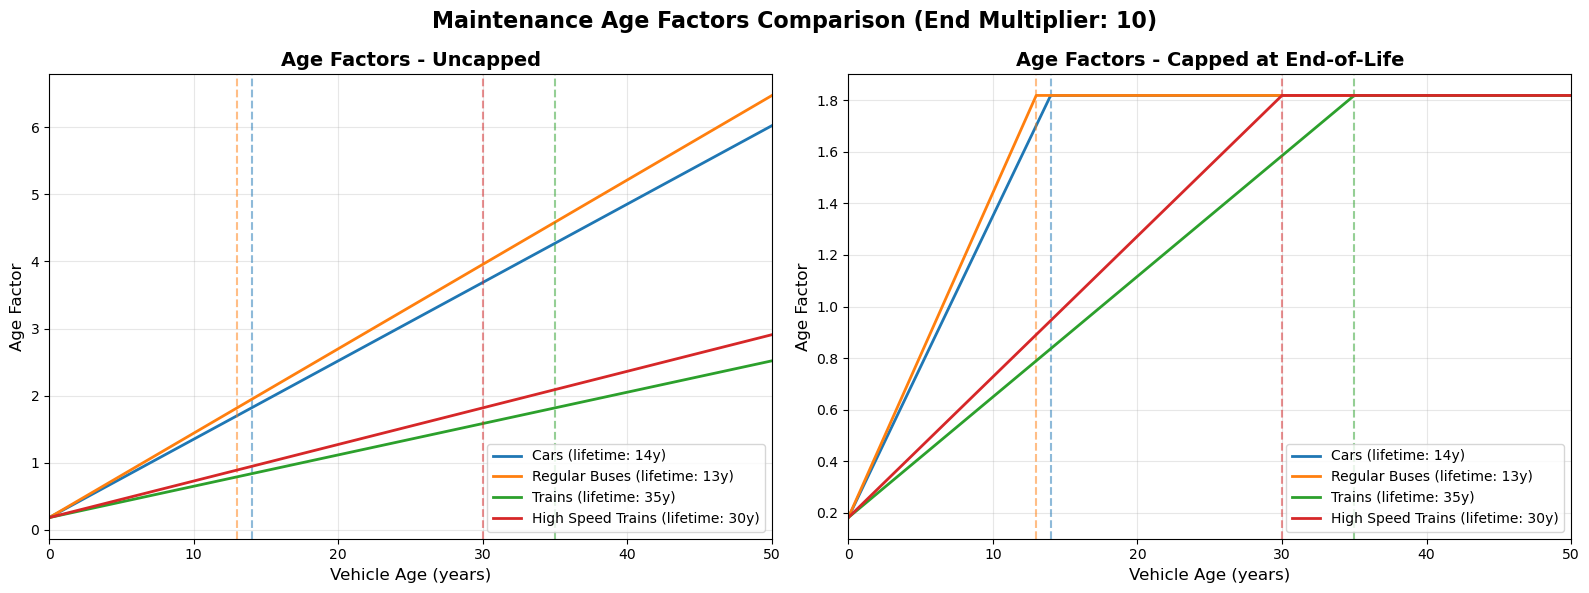


Age Factor Statistics (End Multiplier: 10):
Start Factor: 0.182
End Factor: 1.818

Vehicle Lifetimes:
  Cars: 14 years
  Regular Buses: 13 years
  Trains: 35 years
  High Speed Trains: 30 years


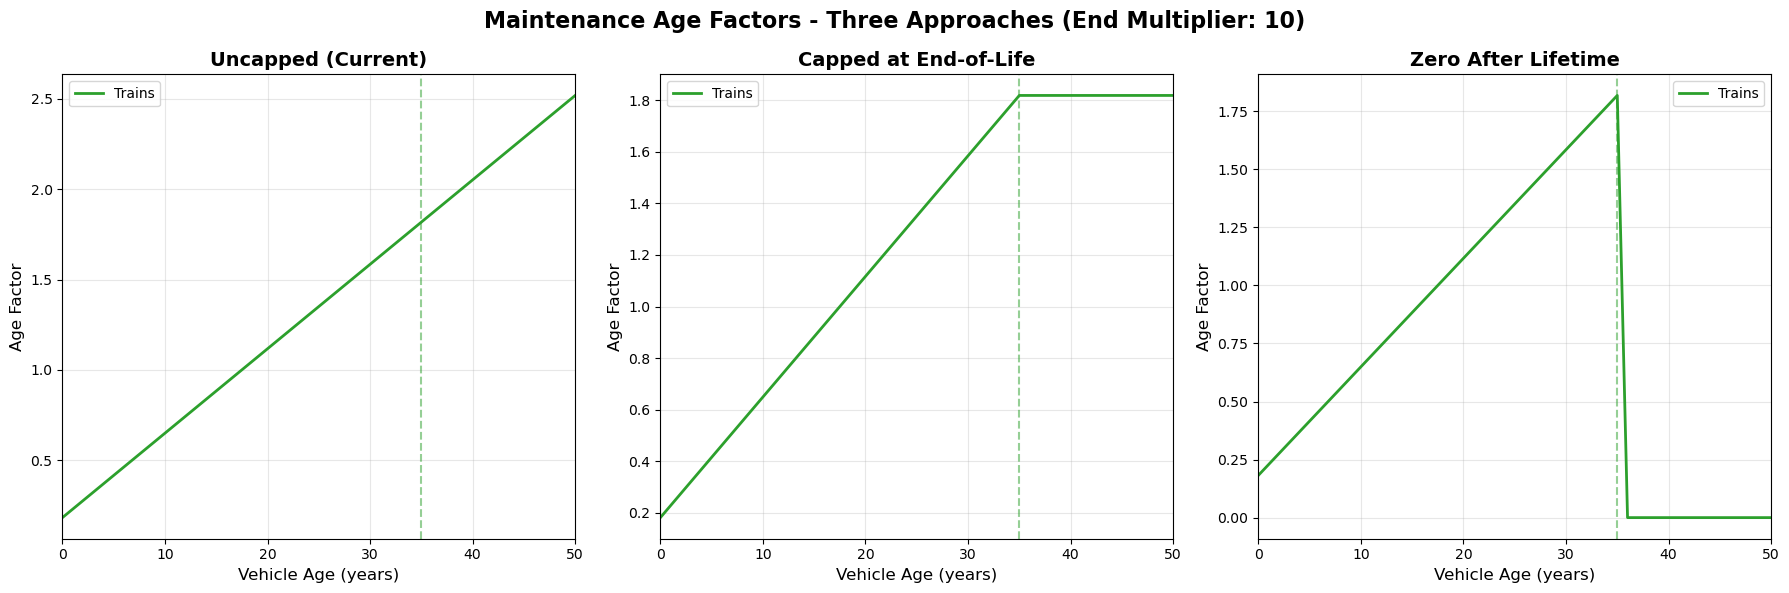

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
from imagematerials.vehicles.constants import maintenance_lifetime_per_mode
from imagematerials.concepts import create_vehicle_graph
#from imagematerials.constants import modes

def plot_age_factors_comparison(end_multiplier=10, max_age=50):
    """
    Plot age factors for different vehicle types with and without capping.
    
    Parameters
    ----------
    end_multiplier : float
        The multiplier for maintenance at end of life
    max_age : int
        Maximum age to plot
    """
    
    # Setup vehicle lifetimes
    maintenance_lifetime_per_mode_ = maintenance_lifetime_per_mode.copy()
    maintenance_lifetime_per_mode_['Vehicles'] = 0
    modes_lifetime = list(maintenance_lifetime_per_mode_.keys())
    
    expected_lifetimes = xr.DataArray(
        data=[maintenance_lifetime_per_mode_[mode] for mode in modes_lifetime],
        dims=["Type"],
        coords={"Type": modes_lifetime},
        name="vehicle_lifetime"
    )
    modes = ["Cars", "Regular Buses", "Trains", "High Speed Trains"]
    vehicle_lifetime_maintenance = create_vehicle_graph().rebroadcast_xarray(
        expected_lifetimes, output_coords=modes, dim="Type"
    )
    
    # Create age array
    ages = np.arange(0, max_age + 1)
    
    # Calculate start factor
    start_factor = 2.0 / (end_multiplier + 1)
    
    # Select a few representative vehicle types
    vehicle_types = modes
    
    # Create subplots
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    
    # Colors for different vehicle types
    colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']
    
    for i, vtype in enumerate(vehicle_types):
        if vtype not in vehicle_lifetime_maintenance.coords["Type"].values:
            continue
            
        lifetime = float(vehicle_lifetime_maintenance.sel(Type=vtype).values)
        
        if lifetime <= 0:
            continue
            
        # Calculate slope
        slope = ((start_factor * end_multiplier) - start_factor) / lifetime
        
        # Calculate uncapped age factors
        uncapped_age_factors = start_factor + slope * ages
        
        # Calculate capped age factors
        max_age_factor = start_factor * end_multiplier
        capped_age_factors = np.where(ages <= lifetime, uncapped_age_factors, max_age_factor)
        
        # Plot uncapped (left subplot)
        ax1.plot(ages, uncapped_age_factors, 
                color=colors[i], linewidth=2, label=f"{vtype} (lifetime: {lifetime:.0f}y)")
        ax1.axvline(x=lifetime, color=colors[i], linestyle='--', alpha=0.5)
        
        # Plot capped (right subplot)
        ax2.plot(ages, capped_age_factors, 
                color=colors[i], linewidth=2, label=f"{vtype} (lifetime: {lifetime:.0f}y)")
        ax2.axvline(x=lifetime, color=colors[i], linestyle='--', alpha=0.5)
    
    # Format left subplot (uncapped)
    ax1.set_title("Age Factors - Uncapped", fontsize=14, fontweight='bold')
    ax1.set_xlabel("Vehicle Age (years)", fontsize=12)
    ax1.set_ylabel("Age Factor", fontsize=12)
    ax1.grid(True, alpha=0.3)
    ax1.legend()
    ax1.set_xlim(0, max_age)
    
    # Format right subplot (capped)
    ax2.set_title("Age Factors - Capped at End-of-Life", fontsize=14, fontweight='bold')
    ax2.set_xlabel("Vehicle Age (years)", fontsize=12)
    ax2.set_ylabel("Age Factor", fontsize=12)
    ax2.grid(True, alpha=0.3)
    ax2.legend()
    ax2.set_xlim(0, max_age)
    
    # Add overall title
    fig.suptitle(f"Maintenance Age Factors Comparison (End Multiplier: {end_multiplier})", 
                fontsize=16, fontweight='bold')
    
    plt.tight_layout()
    plt.show()
    
    # Print some statistics
    print(f"\nAge Factor Statistics (End Multiplier: {end_multiplier}):")
    print(f"Start Factor: {start_factor:.3f}")
    print(f"End Factor: {start_factor * end_multiplier:.3f}")
    print("\nVehicle Lifetimes:")
    for vtype in vehicle_types:
        if vtype in vehicle_lifetime_maintenance.coords["Type"].values:
            lifetime = float(vehicle_lifetime_maintenance.sel(Type=vtype).values)
            print(f"  {vtype}: {lifetime:.0f} years")

def plot_age_factors_with_zero_option(end_multiplier=10, max_age=50):
    """
    Plot age factors with three options: uncapped, capped, and zero after lifetime.
    """
    # Setup (same as above)
    maintenance_lifetime_per_mode_ = maintenance_lifetime_per_mode.copy()
    maintenance_lifetime_per_mode_['Vehicles'] = 0
    modes_lifetime = list(maintenance_lifetime_per_mode_.keys())
    
    expected_lifetimes = xr.DataArray(
        data=[maintenance_lifetime_per_mode_[mode] for mode in modes_lifetime],
        dims=["Type"],
        coords={"Type": modes_lifetime},
        name="vehicle_lifetime"
    )
    
    vehicle_lifetime_maintenance = create_vehicle_graph().rebroadcast_xarray(
        expected_lifetimes, output_coords=modes, dim="Type"
    )
    
    ages = np.arange(0, max_age + 1)
    start_factor = 2.0 / (end_multiplier + 1)
    
    # Create 1x3 subplot
    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 6))
    
    vehicle_types = ["Cars", "Regular Buses", "Trains", "Light Commercial Vehicles"]
    colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']
    
    for i, vtype in enumerate(vehicle_types):
        if vtype not in vehicle_lifetime_maintenance.coords["Type"].values:
            continue
            
        lifetime = float(vehicle_lifetime_maintenance.sel(Type=vtype).values)
        if lifetime <= 0:
            continue
            
        slope = ((start_factor * end_multiplier) - start_factor) / lifetime
        
        # Three scenarios
        uncapped = start_factor + slope * ages
        capped = np.where(ages <= lifetime, uncapped, start_factor * end_multiplier)
        zero_after = np.where(ages <= lifetime, uncapped, 0)
        
        # Plot all three
        ax1.plot(ages, uncapped, color=colors[i], linewidth=2, label=f"{vtype}")
        ax1.axvline(x=lifetime, color=colors[i], linestyle='--', alpha=0.5)
        
        ax2.plot(ages, capped, color=colors[i], linewidth=2, label=f"{vtype}")
        ax2.axvline(x=lifetime, color=colors[i], linestyle='--', alpha=0.5)
        
        ax3.plot(ages, zero_after, color=colors[i], linewidth=2, label=f"{vtype}")
        ax3.axvline(x=lifetime, color=colors[i], linestyle='--', alpha=0.5)
    
    # Format all subplots
    titles = ["Uncapped (Current)", "Capped at End-of-Life", "Zero After Lifetime"]
    axes = [ax1, ax2, ax3]
    
    for ax, title in zip(axes, titles):
        ax.set_title(title, fontsize=14, fontweight='bold')
        ax.set_xlabel("Vehicle Age (years)", fontsize=12)
        ax.set_ylabel("Age Factor", fontsize=12)
        ax.grid(True, alpha=0.3)
        ax.legend()
        ax.set_xlim(0, max_age)
    
    fig.suptitle(f"Maintenance Age Factors - Three Approaches (End Multiplier: {end_multiplier})", 
                fontsize=16, fontweight='bold')
    
    plt.tight_layout()
    plt.show()

# Usage
plot_age_factors_comparison(end_multiplier=10, max_age=50)
plot_age_factors_with_zero_option(end_multiplier=10, max_age=50)

c:\Users\5982758\AppData\Local\anaconda3\envs\materials\lib\site-packages\xarray\core\variable.py:338: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  data = np.asarray(data)
c:\Users\5982758\AppData\Local\anaconda3\envs\materials\lib\site-packages\xarray\core\variable.py:338: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  data = np.asarray(data)
c:\Users\5982758\AppData\Local\anaconda3\envs\materials\lib\site-packages\xarray\core\variable.py:338: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  data = np.asarray(data)
c:\Users\5982758\AppData\Local\anaconda3\envs\materials\lib\site-packages\xarray\core\variable.py:338: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  data = np.asarray(data)


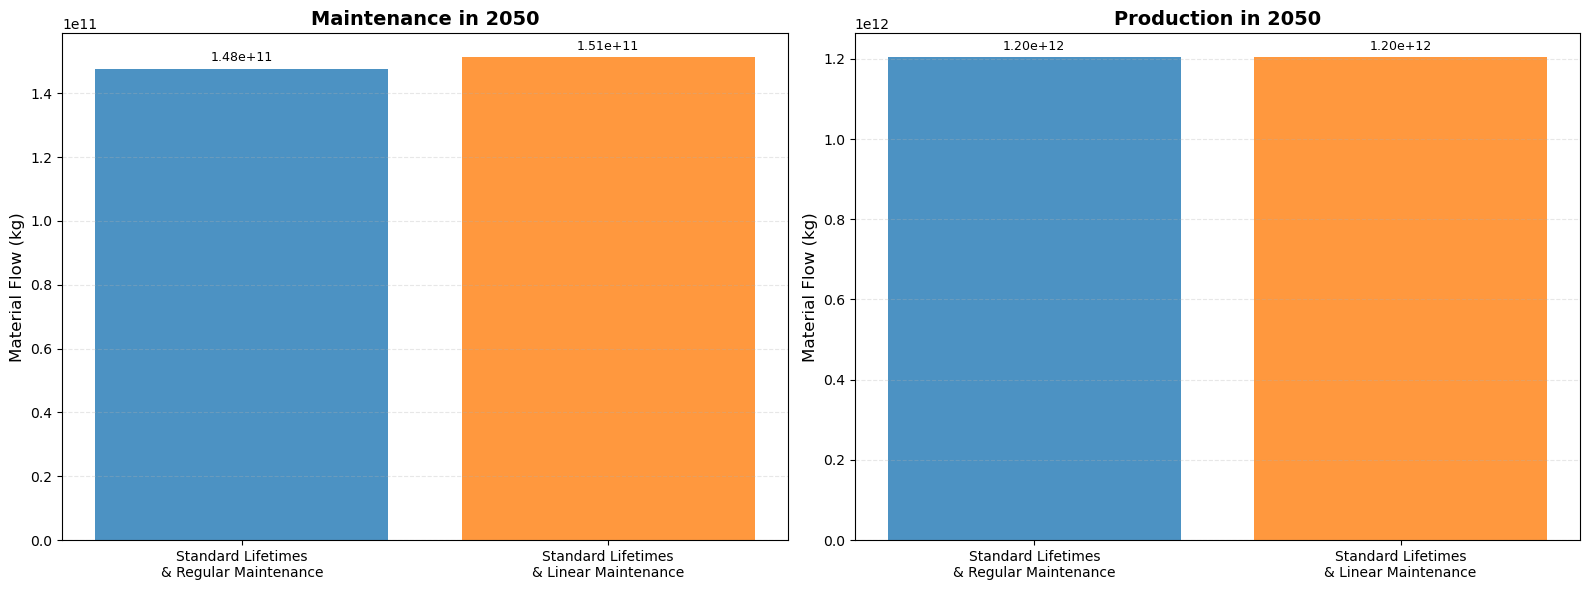


=== Comparison for Year 2050 ===
Standard Lifetimes & Regular Maintenance:
  Maintenance: 1.48e+11 kg
  Production:  1.20e+12 kg
  Ratio (M/P): 0.123
Standard Lifetimes & Linear Maintenance:
  Maintenance: 1.51e+11 kg
  Production:  1.20e+12 kg
  Ratio (M/P): 0.126


c:\Users\5982758\AppData\Local\anaconda3\envs\materials\lib\site-packages\xarray\core\variable.py:338: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  data = np.asarray(data)
c:\Users\5982758\AppData\Local\anaconda3\envs\materials\lib\site-packages\xarray\core\variable.py:338: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  data = np.asarray(data)


ValueError: The number of FixedLocator locations (2), usually from a call to set_ticks, does not match the number of labels (1).

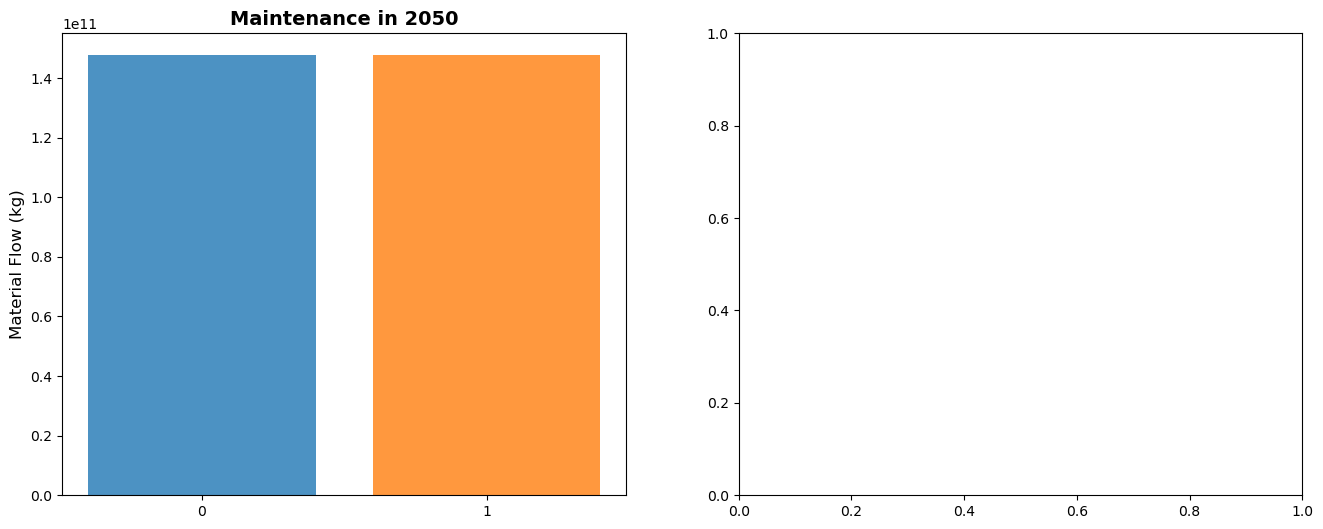

In [ ]:
def plot_scenario_comparison_by_year(all_output, year=2050, scenarios=None):
    """
    Create bar plots comparing production and maintenance across scenarios for a specific year.
    
    Parameters:
    - all_output: Dictionary containing scenario results
    - year: Year to compare (default: 2050)
    - scenarios: List of scenarios to include (default: all scenarios)
    """
    
    if scenarios is None:
        scenarios = list(all_output.keys())
    
    # Collect data for the specified year
    maintenance_data = []
    production_data = []
    scenario_labels = []
    
    for scenario in scenarios:
        if scenario not in all_output:
            print(f"Warning: Scenario {scenario} not found!")
            continue
            
        # Get maintenance data for the year
        maint_array = all_output[scenario]['inflow_maintenance'].sum(dim=['Region', 'Type', 'material'])
        maint_df = maint_array.to_pandas()
        
        if year in maint_df.index:
            maint_value = maint_df.loc[year]
        else:
            print(f"Warning: Year {year} not found in maintenance data for {scenario}")
            maint_value = 0
            
        # Get production data for the year
        prod_array = all_output[scenario]['model'].inflow_materials.to_array().sum(dim=['Region', 'Type', 'material'])
        prod_df = prod_array.to_pandas()
        
        if year in prod_df.index:
            prod_value = prod_df.loc[year]
        else:
            print(f"Warning: Year {year} not found in production data for {scenario}")
            prod_value = 0
        
        maintenance_data.append(maint_value)
        production_data.append(prod_value)
        scenario_labels.append(all_output[scenario]['label'])
    
    # Create bar plot
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    
    x_pos = range(len(scenarios))
    
    # Define colors for scenarios
    scenario_colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']
    colors = scenario_colors[:len(scenarios)]
    
    # Plot maintenance
    bars1 = ax1.bar(x_pos, maintenance_data, color=colors, alpha=0.8)
    ax1.set_title(f'Maintenance in {year}', fontsize=14, fontweight='bold')
    ax1.set_ylabel('Material Flow (kg)', fontsize=12)
    ax1.set_xticks(x_pos)
    ax1.set_xticklabels([label.replace(' & ', '\n& ') for label in scenario_labels], 
                        rotation=0, ha='center', fontsize=10)
    ax1.grid(visible=True, linestyle="--", alpha=0.3, axis='y')
    
    # Add value labels on bars
    for bar, value in zip(bars1, maintenance_data):
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2., height + height*0.01,
                f'{value:.2e}', ha='center', va='bottom', fontsize=9)
    
    # Plot production
    bars2 = ax2.bar(x_pos, production_data, color=colors, alpha=0.8)
    ax2.set_title(f'Production in {year}', fontsize=14, fontweight='bold')
    ax2.set_ylabel('Material Flow (kg)', fontsize=12)
    ax2.set_xticks(x_pos)
    ax2.set_xticklabels([label.replace(' & ', '\n& ') for label in scenario_labels], 
                        rotation=0, ha='center', fontsize=10)
    ax2.grid(visible=True, linestyle="--", alpha=0.3, axis='y')
    
    # Add value labels on bars
    for bar, value in zip(bars2, production_data):
        height = bar.get_height()
        ax2.text(bar.get_x() + bar.get_width()/2., height + height*0.01,
                f'{value:.2e}', ha='center', va='bottom', fontsize=9)
    
    plt.tight_layout()
    plt.show()
    
    # Print summary
    print(f"\n=== Comparison for Year {year} ===")
    for i, scenario in enumerate(scenarios):
        ratio = maintenance_data[i] / production_data[i] if production_data[i] > 0 else 0
        print(f"{scenario_labels[i]}:")
        print(f"  Maintenance: {maintenance_data[i]:.2e} kg")
        print(f"  Production:  {production_data[i]:.2e} kg")
        print(f"  Ratio (M/P): {ratio:.3f}")

def plot_maintenance_production_ratio_comparison(all_output, year=2050, scenarios=None):
    """
    Create a single bar plot showing maintenance/production ratios across scenarios.
    """
    
    if scenarios is None:
        scenarios = list(all_output.keys())
    
    ratios = []
    scenario_labels = []
    
    for scenario in scenarios:
        if scenario not in all_output:
            continue
            
        # Get maintenance and production for the year
        maint_array = all_output[scenario]['inflow_maintenance'].sum(dim=['Region', 'Type', 'material'])
        maint_df = maint_array.to_pandas()
        maint_value = maint_df.loc[year] if year in maint_df.index else 0
        
        prod_array = all_output[scenario]['model'].inflow_materials.to_array().sum(dim=['Region', 'Type', 'material'])
        prod_df = prod_array.to_pandas()
        prod_value = prod_df.loc[year] if year in prod_df.index else 0
        
        ratio = maint_value / prod_value if prod_value > 0 else 0
        ratios.append(ratio)
        scenario_labels.append(all_output[scenario]['label'])
    
    # Create bar plot
    fig, ax = plt.subplots(1, 1, figsize=(12, 6))
    
    x_pos = range(len(scenarios))
    scenario_colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']
    colors = scenario_colors[:len(scenarios)]
    
    bars = ax.bar(x_pos, ratios, color=colors, alpha=0.8)
    ax.set_title(f'Maintenance/Production Ratio in {year}', fontsize=16, fontweight='bold')
    ax.set_ylabel('Maintenance/Production Ratio', fontsize=12)
    ax.set_xticks(x_pos)
    ax.set_xticklabels([label.replace(' & ', '\n& ') for label in scenario_labels], 
                       rotation=0, ha='center', fontsize=10)
    ax.grid(visible=True, linestyle="--", alpha=0.3, axis='y')
    
    # Add value labels on bars
    for bar, ratio in zip(bars, ratios):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + height*0.01,
                f'{ratio:.3f}', ha='center', va='bottom', fontsize=11, fontweight='bold')
    
    plt.tight_layout()
    plt.show()

# Usage examples:
# Compare all scenarios for year 2050
plot_scenario_comparison_by_year(all_output, year=2050)

# Compare specific scenarios for year 2030
plot_scenario_comparison_by_year(all_output, year=2050, 
                                scenarios=['standard_constant', 'slow_constant'])

# Show maintenance/production ratios
#plot_maintenance_production_ratio_comparison(all_output, year=2050)